## Install Modules

In [1]:
# install torch
#!pip install ultralytics

In [2]:
#use lableimg repo/tool to annotate the images

## import modules

In [3]:
import os
import time
import random
import pandas as pd
import numpy as np
import cv2
import torch
from tqdm.auto import tqdm
from PIL import Image
import shutil 
import matplotlib.pyplot as plt
%matplotlib inline

## load  the dataset

In [4]:
df = pd.read_csv("C:/Users/YUG/Downloads/car dataset/data/train_solution_bounding_boxes (1).csv")
df.head()

,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


In [5]:
# get image_id
df['image_id'] = df['image'].apply(lambda x: x.split('.')[0])
df['classes'] = 0
df.head(2)

,image,xmin,ymin,xmax,ymax,image_id,classes
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547,vid_4_1000,0
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180,vid_4_10000,0


In [6]:
# initialize configuration
img_h, img_w, num_channels = (380, 676, 3)
images_folder = "C:/Users/YUG/Downloads/car dataset/data/training_images"

In [7]:
# convert the data points to YOLO format
df['x_center'] = (df['xmin'] + df['xmax']) / 2
df['y_center'] = (df['ymin'] + df['ymax']) / 2
df['w'] = df['xmax'] - df['xmin']
df['h'] = df['ymax'] - df['ymin']

In [8]:
# normalize the values
df['x_center'] = df['x_center'] / img_w
df['y_center'] = df['y_center'] / img_h
df['w'] = df['w'] / img_w
df['h'] = df['h'] / img_h

In [9]:
df.head(2)

,image,xmin,ymin,xmax,ymax,image_id,classes,x_center,y_center,w,h
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547,vid_4_1000,0,0.450434,0.539817,0.068741,0.095238
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180,vid_4_10000,0,0.100217,0.557191,0.155572,0.129987


## Exploratory Data Analysis

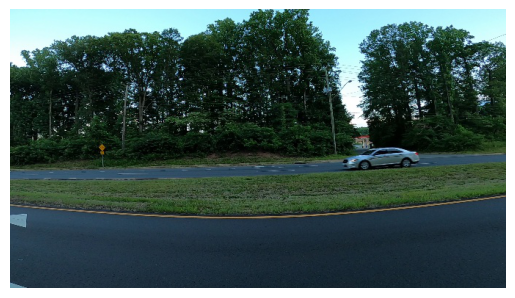

In [10]:
image = random.choice(df['image'])
image_path = os.path.join(images_folder, image)
img = Image.open(image_path)
plt.axis('off')
plt.imshow(img)
plt.show()

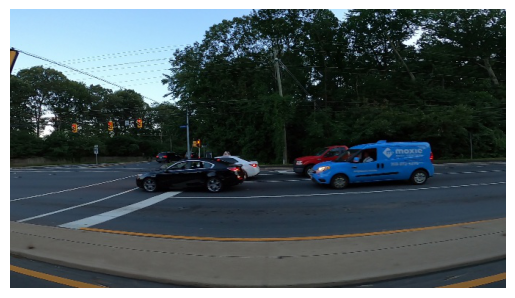

In [11]:
image = random.choice(df['image'])
image_path = os.path.join(images_folder, image)
img = Image.open(image_path)
plt.axis('off')
plt.imshow(img)
plt.show()

In [12]:
def draw_bounding_box(idx):
    image = cv2.imread(os.path.join(images_folder, df['image'][idx]))
    x_min = int(df['xmin'][idx])
    y_min = int(df['ymin'][idx])
    x_max = int(df['xmax'][idx])
    y_max = int(df['ymax'][idx])

    # draw the rectangle
    cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
    # place the lable above bounding boxes
    cv2.putText(image, 'car', (x_min, y_min-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # display the image
    plt.axis('off')
    plt.imshow(image)
    plt.show()

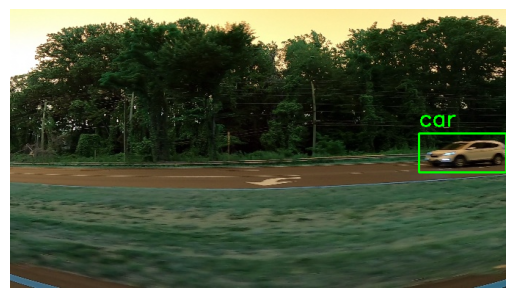

In [13]:
idx = random.randrange(0, len(df))
draw_bounding_box(idx)

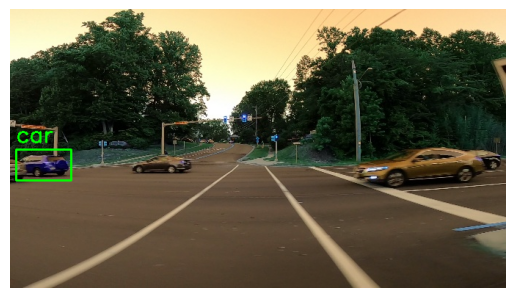

In [14]:
idx = random.randrange(0, len(df))
draw_bounding_box(idx)

## Create Annotation folder for YOLO Format

In [15]:
annotations_folder = 'C:/Users/YUG/Downloads/car dataset/data/annotations/'

if not os.path.exists(annotations_folder):
    os.mkdir(annotations_folder)

In [16]:
annotations_dict = {}

# iterate through dataframe to consolidate bounding boxes forr each image
for _, row in df.iterrows():
    image_file = row['image']
    class_lable = int(row['classes'])
    x_center = row['x_center']
    y_center = row['y_center']
    w = row['w']
    h = row['h']

    # initialize list if image is not present in dicitionary
    if image_file not in annotations_dict:
        annotations_dict[image_file] = []

    # append annotations to the list
    annotations_dict[image_file].append(f"{class_lable} {x_center} {y_center} {w} {h}")

# write the annotations in text file
for image_file, annotations in annotations_dict.items():
    annotation_file = os.path.join(annotations_folder, os.path.splitext(image_file)[0] + '.txt')
    with open(annotation_file, 'w') as f:
        for annotation in annotations:
            f.write(annotation + '\n')

In [17]:
# split images for training and testing
from sklearn.model_selection import train_test_split
images = list(annotations_dict.keys())
train_images, test_images = train_test_split(images, test_size=0.2, random_state=42)

In [18]:
# create folsers for train and test
train_images_folder = 'C:/Users/YUG/Downloads/car dataset/train_images'
test_images_folder = 'C:/Users/YUG/Downloads/car dataset/test_images'
train_annotations_folder = 'C:/Users/YUG/Downloads/car dataset/train_annotations'
test_annotations_folder = 'C:/Users/YUG/Downloads/car dataset/test_annotations'

# cretae directories for the above path
os.makedirs('C:/Users/YUG/Downloads/car dataset', exist_ok=True)
os.makedirs(train_images_folder, exist_ok=True)
os.makedirs(test_images_folder, exist_ok=True)
os.makedirs(train_annotations_folder, exist_ok=True)
os.makedirs(test_annotations_folder, exist_ok=True)

In [19]:
# copy the files to the respective folders path
def copy_files(images_list, image_src_folder, annotation_src_folder, image_dest_folder, annotation_dest_folder):
    for image_file in images_list:
        # path for source and destination
        src_image_path = os.path.join(image_src_folder, image_file)
        annotation_file = os.path.splitext(image_file)[0] + '.txt'
        src_annotations_path = os.path.join(annotation_src_folder, annotation_file)
        dest_image_path = os.path.join(image_dest_folder, image_file)
        dest_annotation_path = os.path.join(annotation_dest_folder, annotation_file)

        # move images
        shutil.copy2(src_image_path, dest_image_path)
        # copy annotations
        shutil.copy2(src_annotations_path, dest_annotation_path)

In [20]:
copy_files(train_images, images_folder, annotations_folder, train_images_folder, train_annotations_folder)
copy_files(test_images, images_folder, annotations_folder, test_images_folder, test_annotations_folder)

## Model Training

In [21]:
!pip install ultralytics

Defaulting to user installation because normal site-packages is not writeable


In [22]:
from ultralytics import YOLO
#load pretrained model
model = YOLO('yolov8n.yaml')

# define training parameters
model.train(
    data='C:/Users/YUG/Downloads/car dataset/data.yaml',
    epochs=60,
    imgsz=640,
    batch=4,
    workers=0
)

New https://pypi.org/project/ultralytics/8.4.19 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.18  Python-3.13.9 torch-2.10.0+cpu CPU (12th Gen Intel Core i5-12500H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/YUG/Downloads/car dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000016A40807690>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [23]:
matrics = model.val()

Ultralytics 8.4.18  Python-3.13.9 torch-2.10.0+cpu CPU (12th Gen Intel Core i5-12500H)
YOLOv8n summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 227.644.2 MB/s, size: 98.8 KB)
val: Scanning C:\Users\YUG\Downloads\car dataset\labels\val.cache... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 9.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.5s/it 7.5s2.2ss
                   all         71        119      0.991      0.915      0.967      0.627
Speed: 0.7ms preprocess, 86.0ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to C:\Users\YUG\runs\detect\val2


In [25]:
# load the weight
best_model = YOLO('yolov8n.yaml')
best_model.load("C:/Users/YUG/runs/detect/train/weights/best.pt")

Transferred 319/355 items from pretrained weights


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

## test with real image

In [26]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

model.predict(
    source="C:/Users/YUG/Downloads/car dataset/test_images/vid_4_10020.jpg",
    conf=0.9,        # increase confidence
    show=True
)


image 1/1 C:\Users\YUG\Downloads\car dataset\test_images\vid_4_10020.jpg: 384x640 (no detections), 99.5ms
Speed: 3.3ms preprocess, 99.5ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car'}
 obb: None
 orig_img: array([[[253, 218, 162],
         [252, 217, 161],
         [252, 217, 161],
         ...,
         [253, 199, 146],
         [253, 199, 146],
         [253, 199, 146]],
 
        [[253, 218, 162],
         [253, 218, 162],
         [253, 218, 162],
         ...,
         [254, 200, 147],
         [254, 200, 147],
         [254, 200, 147]],
 
        [[253, 218, 162],
         [253, 218, 162],
         [254, 219, 163],
         ...,
         [254, 200, 147],
         [254, 200, 147],
         [254, 200, 147]],
 
        ...,
 
        [[ 60,  45,  36],
         [ 58,  43,  34],
         [ 58,  43,  34],
         ...,
         [ 61,  45,  33],
         [ 61,  45,  33],
         [ 62,  46,  34]],
 
        [[ 61,  46,  37],
         [ 60,  45,  36],
         [ 59,  44,  35],
         ...,
         [ 62,  46,  


image 1/1 C:\Users\YUG\Downloads\car dataset\test_images\vid_4_10020.jpg: 384x640 1 car, 98.1ms
Speed: 3.8ms preprocess, 98.1ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


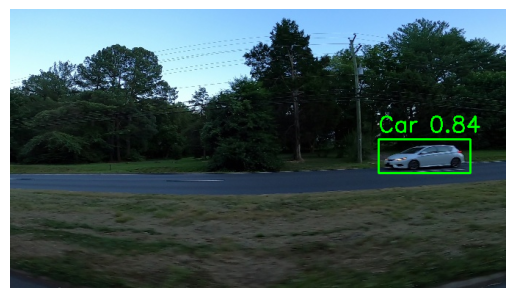

In [27]:
# process the result 
image_path = "C:/Users/YUG/Downloads/car dataset/test_images/vid_4_10020.jpg"
results = model(image_path)
image = cv2.imread(image_path)
for result in results:
    # loopvthrough the detected objects
    for detection in result.boxes:
        x_min, y_min, x_max, y_max = detection.xyxy[0]
        confidence = round(float(detection.conf[0]), 2)
        class_id = int(detection.cls[0])

        #draw bounding box
        cv2.rectangle(image, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 255, 0), 2)

        # write lable
        label = f"Car {confidence}"
        cv2.putText(image, label, (int(x_min), int(y_min)-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# convert the image to rgb
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off')
plt.show()


image 1/1 C:\Users\YUG\Downloads\car dataset\test_images\vid_4_26360.jpg: 384x640 4 cars, 129.3ms
Speed: 4.1ms preprocess, 129.3ms inference, 4.0ms postprocess per image at shape (1, 3, 384, 640)


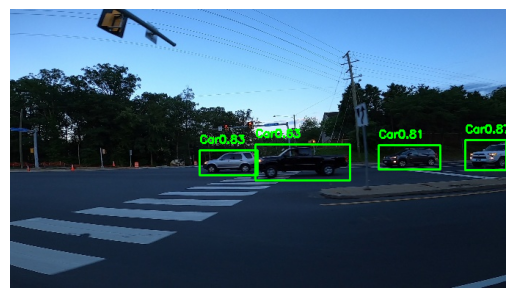

In [28]:
# process the result 
image_path = "C:/Users/YUG/Downloads/car dataset/test_images/vid_4_26360.jpg"
results = model(image_path)
image = cv2.imread(image_path)
for result in results:
    # loopvthrough the detected objects
    for detection in result.boxes:
        x_min, y_min, x_max, y_max = detection.xyxy[0]
        confidence = round(float(detection.conf[0]), 2)
        class_id = int(detection.cls[0])

        #draw bounding box
        cv2.rectangle(image, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 255, 0), 2)

        # write lable
        label = f"Car{confidence}"
        cv2.putText(image, label, (int(x_min), int(y_min)-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# convert the image to rgb
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off')
plt.show()


image 1/1 C:\Users\YUG\Downloads\car dataset\test_images\vid_4_9740.jpg: 384x640 2 cars, 118.0ms
Speed: 4.1ms preprocess, 118.0ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


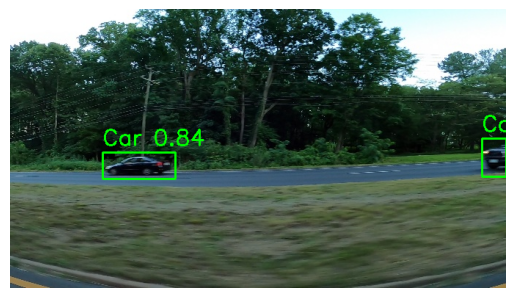

In [29]:
# process the result 
image_path = "C:/Users/YUG/Downloads/car dataset/test_images/vid_4_9740.jpg"
results = model(image_path)
image = cv2.imread(image_path)
for result in results:
    # loopvthrough the detected objects
    for detection in result.boxes:
        x_min, y_min, x_max, y_max = detection.xyxy[0]
        confidence = round(float(detection.conf[0]), 2)
        class_id = int(detection.cls[0])

        #draw bounding box
        cv2.rectangle(image, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 255, 0), 2)

        # write lable
        label = f"Car {confidence}"
        cv2.putText(image, label, (int(x_min), int(y_min)-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# convert the image to rgb
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off')
plt.show()


image 1/1 C:\Users\YUG\Downloads\car dataset\test_images\vid_4_9540.jpg: 384x640 2 cars, 221.9ms
Speed: 5.8ms preprocess, 221.9ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)


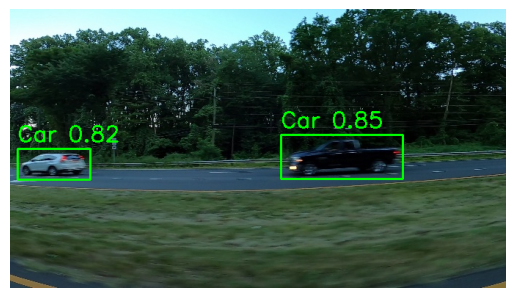

In [4]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

# model.predict(
#     source="C:/Users/YUG/Downloads/car dataset/test_images/vid_4_10020.jpg",
#     conf=0.9,        # increase confidence
#     show=True
# )

# process the result 
image_path = "C:/Users/YUG/Downloads/car dataset/test_images/vid_4_9540.jpg"
results = model(image_path)
image = cv2.imread(image_path)
for result in results:
    # loopvthrough the detected objects
    for detection in result.boxes:
        x_min, y_min, x_max, y_max = detection.xyxy[0]
        confidence = round(float(detection.conf[0]), 2)
        class_id = int(detection.cls[0])

        #draw bounding box
        cv2.rectangle(image, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 255, 0), 2)

        # write lable
        label = f"Car {confidence}"
        cv2.putText(image, label, (int(x_min), int(y_min)-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# convert the image to rgb
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off')
plt.show()


image 1/1 C:\Users\YUG\Downloads\car dataset\test_images\vid_4_10020.jpg: 384x640 (no detections), 199.8ms
Speed: 4.3ms preprocess, 199.8ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\YUG\Downloads\car dataset\test_images\car 1.png: 416x640 1 car, 107.7ms
Speed: 3.0ms preprocess, 107.7ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)


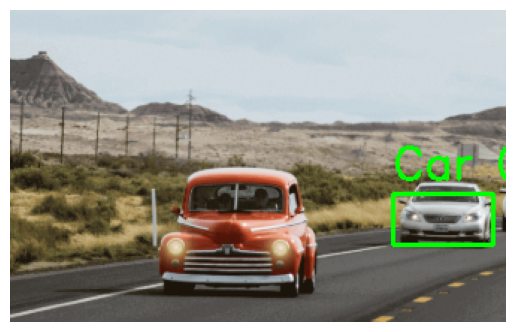

In [7]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

model.predict(
    source="C:/Users/YUG/Downloads/car dataset/test_images/vid_4_10020.jpg",
    conf=0.9,        # increase confidence
    show=True
)

# process the result 
image_path = "C:/Users/YUG/Downloads/car dataset/test_images/car 1.png"
results = model(image_path)
image = cv2.imread(image_path)
for result in results:
    # loopvthrough the detected objects
    for detection in result.boxes:
        x_min, y_min, x_max, y_max = detection.xyxy[0]
        confidence = round(float(detection.conf[0]), 2)
        class_id = int(detection.cls[0])

        #draw bounding box
        cv2.rectangle(image, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 255, 0), 2)

        # write lable
        label = f"Car {confidence}"
        cv2.putText(image, label, (int(x_min), int(y_min)-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# convert the image to rgb
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off')
plt.show()

In [9]:
model = YOLO("runs/detect/train/weights/best.pt")

model.train(data="C:/Users/YUG/Downloads/car dataset/data.yaml", epochs=5)

New https://pypi.org/project/ultralytics/8.4.26 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.18  Python-3.13.9 torch-2.10.0+cpu CPU (12th Gen Intel Core i5-12500H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/YUG/Downloads/car dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/train/weights/best.pt, momentum=0.937, mosaic=1

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001C6C13BC710>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480


image 1/1 C:\Users\YUG\Downloads\car dataset\test_images\car 1.png: 416x640 1 car, 271.8ms
Speed: 6.3ms preprocess, 271.8ms inference, 2.4ms postprocess per image at shape (1, 3, 416, 640)


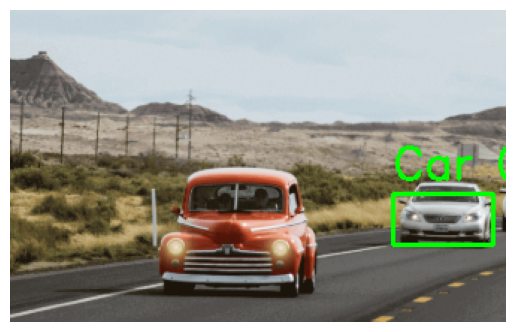

In [12]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

# model.predict(
#     source="C:/Users/YUG/Downloads/car dataset/test_images/vid_4_10020.jpg",
#     conf=0.9,        # increase confidence
#     show=True
# )

# process the result 
image_path = "C:/Users/YUG/Downloads/car dataset/test_images/car 1.png"
results = model(image_path)
image = cv2.imread(image_path)
for result in results:
    # loopvthrough the detected objects
    for detection in result.boxes:
        x_min, y_min, x_max, y_max = detection.xyxy[0]
        confidence = round(float(detection.conf[0]), 2)
        class_id = int(detection.cls[0])

        #draw bounding box
        cv2.rectangle(image, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 255, 0), 2)

        # write lable
        label = f"Car {confidence}"
        cv2.putText(image, label, (int(x_min), int(y_min)-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# convert the image to rgb
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off')
plt.show()

In [13]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

model.train(
    data="C:/Users/YUG/Downloads/car dataset/data.yaml",
    epochs=5,
    imgsz=640
)

New https://pypi.org/project/ultralytics/8.4.26 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.18  Python-3.13.9 torch-2.10.0+cpu CPU (12th Gen Intel Core i5-12500H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/YUG/Downloads/car dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/train/weights/best.pt, momentum=0.937, mosaic=1

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001C6C1D325D0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480


image 1/1 C:\Users\YUG\Downloads\car dataset\test_images\car 1.png: 416x640 1 car, 199.3ms
Speed: 5.8ms preprocess, 199.3ms inference, 2.2ms postprocess per image at shape (1, 3, 416, 640)


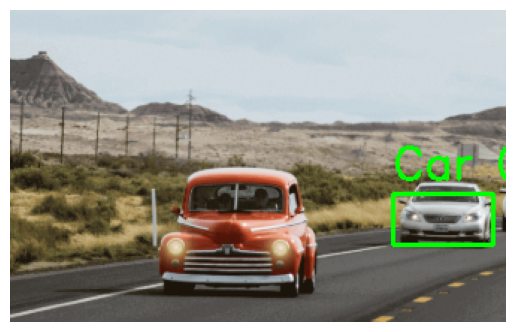

In [14]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

# model.predict(
#     source="C:/Users/YUG/Downloads/car dataset/test_images/vid_4_10020.jpg",
#     conf=0.9,        # increase confidence
#     show=True
# )

# process the result 
image_path = "C:/Users/YUG/Downloads/car dataset/test_images/car 1.png"
results = model(image_path)
image = cv2.imread(image_path)
for result in results:
    # loopvthrough the detected objects
    for detection in result.boxes:
        x_min, y_min, x_max, y_max = detection.xyxy[0]
        confidence = round(float(detection.conf[0]), 2)
        class_id = int(detection.cls[0])

        #draw bounding box
        cv2.rectangle(image, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 255, 0), 2)

        # write lable
        label = f"Car {confidence}"
        cv2.putText(image, label, (int(x_min), int(y_min)-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# convert the image to rgb
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off')
plt.show()